# AFC Championship Exploratory Data Analysis (EDA)
# Jupyter Notebook Project - Professional Practice

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: Larry Parks
- Repository: https://github.com/parkslarryjr/datafun-04-notebooks
- Purpose: Perform exploratory data analysis on AFC Championship game data to identify trends in team performance, yardage, and turnovers between winning and losing teams.
- Date: 2026-01

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

This section sets up the environment for analyzing AFC Championship game data using Python, pandas, seaborn, and matplotlib.

In [74]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("AFC-EDA-NB", level="DEBUG")
log_header(LOG, "AFC-EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# Dataset name (used later in Section 2 when loading data)
DATASET_NAME: Final[str] = "afc_championship"

# Grouping column (for comparisons in analysis)
GROUP_COL: Final[str] = "WT_Team"

# Numeric columns to analyze (AFC Championship dataset)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "WT_Rush_Yards",
    "WT_Pass_Yards",
    "WT_Total_Yards",
    "LT_Rush_Yards",
    "LT_Pass_Yards",
    "LT_Total_Yards",
    "WT_Turnovers",
    "LT_Turnovers",
]

# === Section 1d. Pandas Configuration for Display ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("AFC Championship EDA setup complete.")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | === RUN START ===
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | project=AFC-EDA-NB
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | repo_dir=datafun-04-notebooks
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | python=3.14.5
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | os=Windows 11
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | shell=powershell
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | cwd=notebooks
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | github_actions=False
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship EDA setup complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the AFC Championship dataset to confirm:

- The dataset loads successfully
- The structure matches expectations for game statistics
- Column names are available and readable for team performance analysis

This is a Markdown cell.

In [75]:
# Python cell

# Load AFC Championship dataset into a DataFrame.

# This dataset is stored locally as a CSV file.
# We load it using pandas instead of seaborn built-in datasets.

LOG.info(f"Loading dataset: {DATASET_NAME}")

df: pd.DataFrame = pd.read_csv("../data/raw/afc_championship.csv")

LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Clean column names for easier analysis (standardize formatting)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("#", "")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Loading dataset: afc_championship
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Loaded: 53 rows, 13 columns


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist in the AFC Championship dataset,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present (team names vs numeric game stats)?
- Are there missing values or inconsistencies in game records?

This step helps identify issues in the dataset before performing analysis of team performance trends.

This is a Markdown cell.

In [76]:
# Section 3 Python cell

# Preview the first few rows of the AFC Championship dataset
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.

LOG.info("Previewing first few rows of the AFC Championship dataset")
display(df.head())

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Previewing first few rows of the AFC Championship dataset


,Year,Winning_Team_(WT),Final_Score,Losing_Team_(LT),Final_Score,WT_Rush_Yards,WT_Pass_Yards,WT_Total_Yards,LT_Rush_Yards,LT_Pass_Yards,LT_Total_Yards,WT_turnovers,LT_turnovers
0,1970,Baltimore Colts,27,Oakland Raiders,17,126,237,363,107,229,336,0,4
1,1971,Miami Dolphins,21,Baltimore Colts,0,144,142,286,89,209,298,1,3
2,1972,Miami Dolphins,21,Pittsburgh Steelers,17,193,121,314,128,122,250,1,2
3,1973,Miami Dolphins,27,Oakland Raiders,10,266,26,292,107,129,236,1,1
4,1974,Pittsburgh Steelers,24,Oakland Raiders,13,224,95,319,29,249,278,3,3


In [77]:
# Section 3 Python cell

LOG.info("AFC Championship dataset column names")
print(list(df.columns))

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship dataset column names


['Year', 'Winning_Team_(WT)', 'Final_Score', 'Losing_Team_(LT)', 'Final_Score', 'WT_Rush_Yards', 'WT_Pass_Yards', 'WT_Total_Yards', 'LT_Rush_Yards', 'LT_Pass_Yards', 'LT_Total_Yards', 'WT_turnovers', 'LT_turnovers']


In [78]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.

LOG.info("AFC Championship dataset info (types and non-null counts)")
df.info()

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship dataset info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Year               53 non-null     int64
 1   Winning_Team_(WT)  53 non-null     str  
 2   Final_Score        53 non-null     int64
 3   Losing_Team_(LT)   53 non-null     str  
 4   Final_Score        53 non-null     int64
 5   WT_Rush_Yards      53 non-null     int64
 6   WT_Pass_Yards      53 non-null     int64
 7   WT_Total_Yards     53 non-null     int64
 8   LT_Rush_Yards      53 non-null     int64
 9   LT_Pass_Yards      53 non-null     int64
 10  LT_Total_Yards     53 non-null     int64
 11  WT_turnovers       53 non-null     int64
 12  LT_turnovers       53 non-null     int64
dtypes: int64(11), str(2)
memory usage: 5.5 KB


In [79]:
# Section 3 Python cell

# Get shape - number of rows and columns in the AFC Championship dataset
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# Unpack tuple into separate variables for clarity
num_rows, num_cols = shape

LOG.info(f"AFC Championship dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship dataset shape: 53 rows, 13 columns


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps understand the structure and quality of the AFC Championship dataset.

WHY: Missing or inconsistent data is common in real-world sports datasets and must be identified before analysis.

Missing data affects:

- Visualizations of game performance
- Summary statistics (yards, turnovers, scores)
- Any comparisons between winning and losing teams

LOOK FOR:

- Columns with missing game statistics
- Incomplete or inconsistent team records
- Patterns in missing values across specific seasons or variables

This is a Markdown cell.


In [80]:
# Section 4 Python cell

LOG.info("Building AFC Championship dataset data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Building AFC Championship dataset data dictionary
2026-06-02 08:22:51 | DEBUG | AFC-EDA-NB | 
               column  dtype  missing_count  missing_pct
0                Year  int64              0          0.0
1   Winning_Team_(WT)    str              0          0.0
2         Final_Score  int64              0          0.0
3    Losing_Team_(LT)    str              0          0.0
4         Final_Score  int64              0          0.0
5       WT_Rush_Yards  int64              0          0.0
6       WT_Pass_Yards  int64              0          0.0
7      WT_Total_Yards  int64              0          0.0
8       LT_Rush_Yards  int64              0          0.0
9       LT_Pass_Yards  int64              0          0.0
10     LT_Total_Yards  int64              0          0.0
11       WT_turnovers  int64              0          0.0
12       LT_turnovers  int64              0          0.0


In [81]:
# Section 4 Python cell

LOG.info("AFC Championship dataset missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column (sorted)")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"AFC Championship dataset duplicate rows detected: {dup_count}")

LOG.info("Summary statistics for AFC Championship numeric columns")
LOG.debug(f"\n{df.select_dtypes(include='number').describe()}\n")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship dataset missing values per column:
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Year                 0
Winning_Team_(WT)    0
Final_Score          0
Losing_Team_(LT)     0
Final_Score          0
WT_Rush_Yards        0
WT_Pass_Yards        0
WT_Total_Yards       0
LT_Rush_Yards        0
LT_Pass_Yards        0
LT_Total_Yards       0
WT_turnovers         0
LT_turnovers         0
dtype: int64
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Checking missing values per column (sorted)
2026-06-02 08:22:51 | DEBUG | AFC-EDA-NB | 
Year                 0
Winning_Team_(WT)    0
Final_Score          0
Losing_Team_(LT)     0
Final_Score          0
WT_Rush_Yards        0
WT_Pass_Yards        0
WT_Total_Yards       0
LT_Rush_Yards        0
LT_Pass_Yards        0
LT_Total_Yards       0
WT_turnovers         0
LT_turnovers         0
dtype: int64
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC Championship dataset duplicate rows detected: 0
2026-06-02 08:22

## Section 5. Create Clean View for EDA

Create a cleaned view of the AFC Championship dataset for exploratory analysis.

Strategy:
  - Keep the original DataFrame unchanged
  - Ensure consistent formatting of team statistics
  - Focus analysis on complete numeric game performance data (yards, scores, turnovers)

WHY: Even though this dataset contains no missing values, creating a clean view ensures consistent structure for analysis and makes it easier to compute statistics and generate visualizations.

This step prepares the dataset for comparison of offensive and defensive performance across championship games.

In [82]:
# Section 5 Python cell

# Create a clean working copy of the AFC Championship dataset
# Even though there are no missing values, we still create a clean view
# for consistency and safe analysis practices.

df_clean: pd.DataFrame = df.copy()

# (Optional) ensure column names are consistent and readable
df_clean.columns = df_clean.columns.str.strip()

# Confirm dataset size is unchanged
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]

LOG.info(f"AFC dataset original rows: {count_original}")
LOG.info(f"AFC dataset clean rows: {count_clean}")
LOG.info("No rows removed - dataset already complete")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC dataset original rows: 53
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | AFC dataset clean rows: 53
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | No rows removed - dataset already complete


## Section 6. Descriptive Statistics for AFC Championship Game Data

WHY: Summary statistics help us understand how teams performed in high-stakes AFC Championship games.

This includes:
- Offensive production (rushing, passing, total yards)
- Defensive impact (yards allowed, turnovers forced)
- Overall game balance between winning and losing teams

We use descriptive statistics to:
- Compare winning vs losing team performance
- Identify typical ranges of yardage in championship games
- Understand how turnovers and yardage relate to outcomes
- Observe differences in performance across different eras of the NFL

This step helps reveal patterns in what separates winning teams from losing teams in championship-level football.

In [83]:
LOG.info("--------------- AFC Championship Manual Statistics ---------------")

# Example: Offensive performance (Winning Team Total Yards)
mean_wt_yards = np.mean(df_clean["WT_Total_Yards"])
std_wt_yards = np.std(df_clean["WT_Total_Yards"])
min_wt_yards = np.min(df_clean["WT_Total_Yards"])
max_wt_yards = np.max(df_clean["WT_Total_Yards"])
range_wt_yards = max_wt_yards - min_wt_yards

LOG.info("Winning Team Total Yards Statistics:")
LOG.info(f"  Mean: {mean_wt_yards:.2f}")
LOG.info(f"  Std Dev: {std_wt_yards:.2f}")
LOG.info(f"  Min: {min_wt_yards}")
LOG.info(f"  Max: {max_wt_yards}")
LOG.info(f"  Range: {range_wt_yards}")

# Example: Losing Team Total Yards comparison
mean_lt_yards = np.mean(df_clean["LT_Total_Yards"])
std_lt_yards = np.std(df_clean["LT_Total_Yards"])
min_lt_yards = np.min(df_clean["LT_Total_Yards"])
max_lt_yards = np.max(df_clean["LT_Total_Yards"])
range_lt_yards = max_lt_yards - min_lt_yards

LOG.info("Losing Team Total Yards Statistics:")
LOG.info(f"  Mean: {mean_lt_yards:.2f}")
LOG.info(f"  Std Dev: {std_lt_yards:.2f}")
LOG.info(f"  Min: {min_lt_yards}")
LOG.info(f"  Max: {max_lt_yards}")
LOG.info(f"  Range: {range_lt_yards}")

# Example: Turnover impact (often important in football outcomes)
mean_wt_turnovers = np.mean(df_clean["WT_turnovers"])
mean_lt_turnovers = np.mean(df_clean["LT_turnovers"])

LOG.info("Turnover Averages:")
LOG.info(f"  Winning Teams Avg Turnovers: {mean_wt_turnovers:.2f}")
LOG.info(f"  Losing Teams Avg Turnovers: {mean_lt_turnovers:.2f}")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | --------------- AFC Championship Manual Statistics ---------------
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Winning Team Total Yards Statistics:
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Mean: 349.26
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Std Dev: 81.92
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Min: 198
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Max: 569
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Range: 371
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Losing Team Total Yards Statistics:
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Mean: 311.06
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Std Dev: 73.06
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Min: 142
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Max: 464
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Range: 322
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Turnover Averages:
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |   Winning Teams Avg Turnovers: 1.51
2026-06-02 08:22:51 | INFO | AFC-EDA-NB |

In [84]:
LOG.info("--------------- AFC Championship Descriptive Statistics ---------------")

# Overall descriptive statistics for all numeric game data
stats_overall = df_clean.select_dtypes(include="number").describe().T
LOG.info("Overall AFC Championship Statistics:")
LOG.debug(f"\n{stats_overall}")

# -------------------------------
# Group comparison: Winning vs Losing team performance averages
# -------------------------------

LOG.info("Computing simplified group-style comparisons (WT vs LT performance)")

group_summary = pd.DataFrame(
    {
        "Winning_Team_Avg": [
            df_clean["WT_Rush_Yards"].mean(),
            df_clean["WT_Pass_Yards"].mean(),
            df_clean["WT_Total_Yards"].mean(),
            df_clean["WT_turnovers"].mean(),
        ],
        "Losing_Team_Avg": [
            df_clean["LT_Rush_Yards"].mean(),
            df_clean["LT_Pass_Yards"].mean(),
            df_clean["LT_Total_Yards"].mean(),
            df_clean["LT_turnovers"].mean(),
        ],
    },
    index=["Rush Yards", "Pass Yards", "Total Yards", "Turnovers"],
)

LOG.info("Winning vs Losing Team Averages:")
LOG.debug(f"\n{group_summary}")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | --------------- AFC Championship Descriptive Statistics ---------------
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Overall AFC Championship Statistics:
2026-06-02 08:22:51 | DEBUG | AFC-EDA-NB | 
                count         mean        std     min     25%     50%     75%     max
Year             53.0  1996.000000  15.443445  1970.0  1983.0  1996.0  2009.0  2022.0
Final_Score      53.0    27.849057   8.549395    10.0    23.0    27.0    34.0    51.0
Final_Score      53.0    15.622642   7.920826     0.0    10.0    16.0    20.0    34.0
WT_Rush_Yards    53.0   135.132075  51.571473    42.0   101.0   126.0   175.0   266.0
WT_Pass_Yards    53.0   214.132075  92.870058    26.0   160.0   205.0   268.0   435.0
WT_Total_Yards   53.0   349.264151  82.707815   198.0   289.0   347.0   389.0   569.0
LT_Rush_Yards    53.0    88.094340  36.501456    14.0    66.0    86.0   107.0   163.0
LT_Pass_Yards    53.0   222.962264  68.708963    70.0   188.0   225.0   256

In [85]:
LOG.info("--------------- AFC Championship Insight Summary ---------------")

# Create simple, readable comparison of key performance differences

wt_avg_yards = df_clean["WT_Total_Yards"].mean()
lt_avg_yards = df_clean["LT_Total_Yards"].mean()

wt_avg_turnovers = df_clean["WT_turnovers"].mean()
lt_avg_turnovers = df_clean["LT_turnovers"].mean()

yard_difference = wt_avg_yards - lt_avg_yards
turnover_difference = lt_avg_turnovers - wt_avg_turnovers

LOG.info("Key AFC Championship Insights:")

LOG.info(f"Winning teams average total yards: {wt_avg_yards:.2f}")
LOG.info(f"Losing teams average total yards:  {lt_avg_yards:.2f}")
LOG.info(f"Average yardage advantage:         {yard_difference:.2f}")

LOG.info(f"Winning teams avg turnovers: {wt_avg_turnovers:.2f}")
LOG.info(f"Losing teams avg turnovers:  {lt_avg_turnovers:.2f}")
LOG.info(f"Turnover disadvantage for losers: {turnover_difference:.2f}")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | --------------- AFC Championship Insight Summary ---------------
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Key AFC Championship Insights:
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Winning teams average total yards: 349.26
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Losing teams average total yards:  311.06
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Average yardage advantage:         38.21
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Winning teams avg turnovers: 1.51
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Losing teams avg turnovers:  3.02
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Turnover disadvantage for losers: 1.51


## Section 7. Relationships Between Game Performance Metrics

We examine correlations between key AFC Championship performance statistics to understand how different aspects of gameplay are related.

This includes relationships between:
- Rushing and passing performance
- Total offensive yards and scoring outcomes
- Turnovers and overall yardage production

WHY: Correlation helps identify which game factors tend to move together and which may influence winning outcomes.

In the context of football:
- Strong positive correlation suggests two metrics increase together (e.g., passing yards and total yards)
- Strong negative correlation suggests an inverse relationship (e.g., turnovers vs. winning performance)
- Weak correlation suggests little direct relationship between variables

This analysis helps reveal which performance factors are most strongly associated with successful championship outcomes.

In [86]:
LOG.info("--------------- AFC Championship Correlation Analysis ---------------")

# Compute correlation matrix for all numeric AFC game statistics
numeric_df: pd.DataFrame = df_clean.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

LOG.info("Correlation matrix computed for AFC Championship dataset")
LOG.debug(f"\n{correlation_matrix}")

# Focus on key relationships that matter in football outcomes

LOG.info("--------------- Key AFC Insight Correlations ---------------")

# Total yards relationship (most important football metric)
wt_corr = correlation_matrix.loc["WT_Total_Yards", "WT_Pass_Yards"]
lt_corr = correlation_matrix.loc["LT_Total_Yards", "LT_Pass_Yards"]

LOG.info(f"WT Total Yards vs Pass Yards correlation: {wt_corr:.2f}")
LOG.info(f"LT Total Yards vs Pass Yards correlation: {lt_corr:.2f}")

# Turnover relationships (critical for winning)
turnover_corr_wt = correlation_matrix.loc["WT_turnovers", "WT_Total_Yards"]
turnover_corr_lt = correlation_matrix.loc["LT_turnovers", "LT_Total_Yards"]

LOG.info(f"WT Turnovers vs Total Yards correlation: {turnover_corr_wt:.2f}")
LOG.info(f"LT Turnovers vs Total Yards correlation: {turnover_corr_lt:.2f}")

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | --------------- AFC Championship Correlation Analysis ---------------
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Correlation matrix computed for AFC Championship dataset
2026-06-02 08:22:51 | DEBUG | AFC-EDA-NB | 
                    Year  Final_Score  Final_Score  WT_Rush_Yards  WT_Pass_Yards  WT_Total_Yards  LT_Rush_Yards  \
Year            1.000000     0.187746     0.377148      -0.484197       0.479216        0.236181       0.008836   
Final_Score     0.187746     1.000000     0.430795       0.221706       0.537966        0.742307       0.324806   
Final_Score     0.377148     0.430795     1.000000      -0.202310       0.554660        0.496663       0.256738   
WT_Rush_Yards  -0.484197     0.221706    -0.202310       1.000000      -0.463924        0.102612      -0.071855   
WT_Pass_Yards   0.479216     0.537966     0.554660      -0.463924       1.000000        0.833595       0.162164   
WT_Total_Yards  0.236181     0.742307     0.496663     

2026-06-02 08:22:51 | INFO | AFC-EDA-NB | --------- AFC Championship Correlation Heatmap (Focused) ---------
2026-06-02 08:22:51 | INFO | AFC-EDA-NB | Correlation matrix computed for AFC Championship key metrics
2026-06-02 08:22:51 | DEBUG | AFC-EDA-NB | 
                WT_Rush_Yards  WT_Pass_Yards  WT_Total_Yards  WT_turnovers  LT_Rush_Yards  LT_Pass_Yards  \
WT_Rush_Yards        1.000000      -0.463924        0.102612      0.242235      -0.071855      -0.234539   
WT_Pass_Yards       -0.463924       1.000000        0.833595     -0.221794       0.162164       0.328985   
WT_Total_Yards       0.102612       0.833595        1.000000     -0.098003       0.137284       0.223163   
WT_turnovers         0.242235      -0.221794       -0.098003      1.000000      -0.018330      -0.370275   
LT_Rush_Yards       -0.071855       0.162164        0.137284     -0.018330       1.000000      -0.122109   
LT_Pass_Yards       -0.234539       0.328985        0.223163     -0.370275      -0.122109       

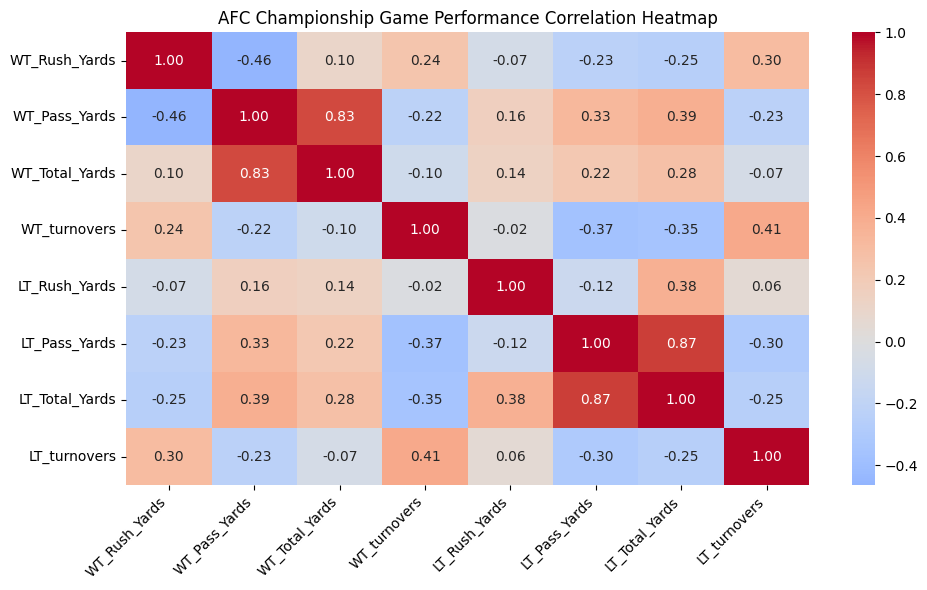

2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Heatmap created showing relationships between AFC performance metrics


In [87]:
LOG.info("--------- AFC Championship Correlation Heatmap (Focused) ---------")

# Select only key AFC performance metrics (not everything)
afc_metrics = df_clean[
    [
        "WT_Rush_Yards",
        "WT_Pass_Yards",
        "WT_Total_Yards",
        "WT_turnovers",
        "LT_Rush_Yards",
        "LT_Pass_Yards",
        "LT_Total_Yards",
        "LT_turnovers",
    ]
]

# Compute correlation matrix
correlation_matrix = afc_metrics.corr()

LOG.info("Correlation matrix computed for AFC Championship key metrics")
LOG.debug(f"\n{correlation_matrix}")

# Create heatmap visualization
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("AFC Championship Game Performance Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


LOG.info("Heatmap created showing relationships between AFC performance metrics")

CUSTOM: Update these notes and use Markdown cells to narrate and tell the story as you explore. For example:

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **LT_Rush_Yards** and **WT_turnovers** show little or no linear relationship (~-.02).

This is a Markdown cell.

## Section 8. Visualizing AFC Championship Game Performance

We use visualizations to better understand performance differences in AFC Championship games.

WHY: Charts help reveal patterns in game performance that are not obvious from raw numbers or summary statistics.

In this analysis, we use three main types of plots:

### 1. Scatter Plot (Relationships Between Metrics)
A scatter plot helps us understand how two performance variables are related.

In AFC Championship context:
- Each point represents one game
- We can compare offensive output between rushing and passing yards
- We can observe how total yardage relates to winning performance

### 2. Box Plot (Comparing Distributions)
A box plot helps compare how performance metrics vary across games.

In this context:
- We can compare rushing, passing, or total yards across championship games
- We can observe consistency vs variability in team performance
- Outliers may represent unusually dominant or low-performing games

### 3. Histogram (Distribution of Performance)
A histogram shows how values are distributed across all AFC Championship games.

In this dataset:
- We can see how total yards are distributed across teams
- We can identify whether most games cluster around similar performance levels
- We can detect whether extreme performances are rare or common

Overall, these visualizations help identify what separates winning and losing teams in high-stakes AFC Championship games.

2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ---- Creating Scatter Plot: AFC Offensive Relationships ------
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ----   Using AFC Championship dataset ------------------------


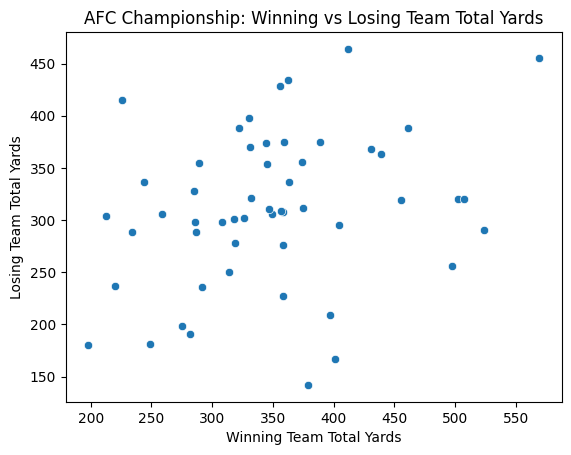

In [88]:
LOG.info("---- Creating Scatter Plot: AFC Offensive Relationships ------")
LOG.info("----   Using AFC Championship dataset ------------------------")

# Scatter plot: Winning vs Losing total yardage comparison
scatter_plt: Axes = sns.scatterplot(
    data=df_clean, x="WT_Total_Yards", y="LT_Total_Yards"
)

# Axis labels
scatter_plt.set_xlabel("Winning Team Total Yards")
scatter_plt.set_ylabel("Losing Team Total Yards")

# Title
scatter_plt.set_title("AFC Championship: Winning vs Losing Team Total Yards")

plt.show()

2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ------- Creating Box Plot: AFC Performance Distribution -------
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ------ Box Plot: Comparing Winning vs Losing Team Metrics ------


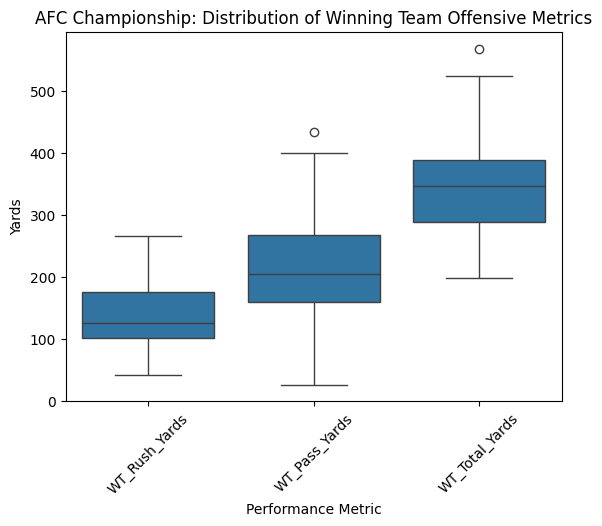

In [89]:
LOG.info("------- Creating Box Plot: AFC Performance Distribution -------")
plt.figure()

LOG.info("------ Box Plot: Comparing Winning vs Losing Team Metrics ------")

# Reshape data into long-form style for comparison
box_data = pd.melt(
    df_clean,
    value_vars=["WT_Rush_Yards", "WT_Pass_Yards", "WT_Total_Yards"],
    var_name="Metric",
    value_name="Yards",
)

# Box plot to compare distribution of winning team performance metrics
box_plt: Axes = sns.boxplot(data=box_data, x="Metric", y="Yards")

box_plt.set_title("AFC Championship: Distribution of Winning Team Offensive Metrics")
box_plt.set_xlabel("Performance Metric")
box_plt.set_ylabel("Yards")

plt.xticks(rotation=45)
plt.show()

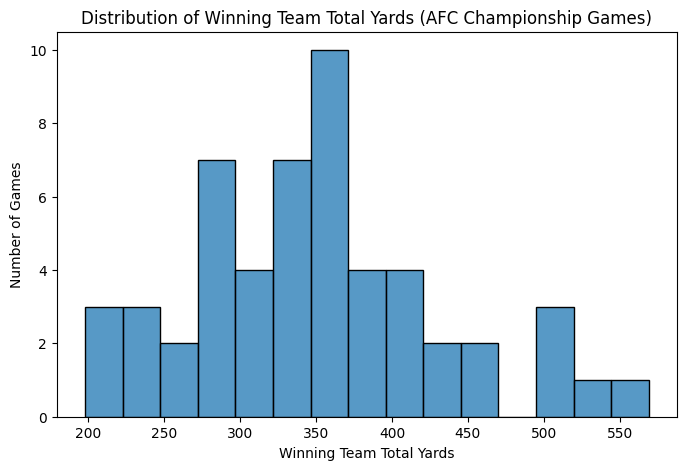

2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Created histogram showing distribution of winning team total yards.
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Insight: Most AFC Championship winners fall in a mid-to-high total yardage range, suggesting consistent offensive production is a strong indicator of success.


In [90]:
# Histogram of AFC Championship Winning Team Total Yards

plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x="WT_Total_Yards", bins=15)

plt.title("Distribution of Winning Team Total Yards (AFC Championship Games)")
plt.xlabel("Winning Team Total Yards")
plt.ylabel("Number of Games")

plt.show()

# Log entry
LOG.info("Created histogram showing distribution of winning team total yards.")

# Insight
LOG.info(
    "Insight: Most AFC Championship winners fall in a mid-to-high total yardage range, "
    "suggesting consistent offensive production is a strong indicator of success."
)

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [91]:
LOG.info("========================")
LOG.info("AFC CHAMPIONSHIP SUMMARY")
LOG.info("========================")

LOG.info("Dataset: AFC Championship Games")
LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Unique winning teams
unique_winners = sorted(df_clean["Winning_Team_(WT)"].unique())
LOG.info(f"Unique AFC Champions: {unique_winners}")

# Key statistical insights
avg_wt_yards = df_clean["WT_Total_Yards"].mean()
avg_lt_yards = df_clean["LT_Total_Yards"].mean()

avg_wt_turnovers = df_clean["WT_turnovers"].mean()
avg_lt_turnovers = df_clean["LT_turnovers"].mean()

LOG.info("Key Insights:")
LOG.info(f"Average Winning Team Total Yards: {avg_wt_yards:.2f}")
LOG.info(f"Average Losing Team Total Yards:  {avg_lt_yards:.2f}")

LOG.info(f"Average Winning Team Turnovers:   {avg_wt_turnovers:.2f}")
LOG.info(f"Average Losing Team Turnovers:    {avg_lt_turnovers:.2f}")

LOG.info("Interpretation:")
LOG.info(
    "Winning teams consistently produce higher offensive yardage and fewer turnovers."
)
LOG.info("Turnovers appear to be a key differentiator in AFC Championship outcomes.")

LOG.info("========================")
LOG.info("AFC EDA WORKFLOW COMPLETE")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ========================
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | AFC CHAMPIONSHIP SUMMARY
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | ========================
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Dataset: AFC Championship Games
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Original rows: 53
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Clean rows:    53
2026-06-02 08:22:52 | INFO | AFC-EDA-NB | Unique AFC Champions: ['Baltimore Colts\xa0', 'Baltimore Ravens\xa0', 'Buffalo Bills', 'Buffalo Bills\xa0', 'Cincinnati Bengals', 'Cincinnati Bengals\xa0', 'Denver Broncos', 'Denver Broncos\xa0', 'Indianapolis Colts\xa0', 'Kansas City Chiefs', 'Kansas City Chiefs\xa0', 'Los Angeles Raiders', 'Miami Dolphins', 'Miami Dolphins\xa0', 'New England Patriots', 'New England Patriots\xa0', 'Oakland Raiders', 'Oakland Raiders\xa0', 'Pittsburgh Steelers', 'Pittsburgh Steelers\xa0', 'San Diego Chargers\xa0', 'Tennessee Titans\xa0']
2026-06-02 08:22:52 | INFO | AFC-EDA

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
